In [ ]:
# ID3 Decision Tree on the ASLG PC12 Dataset

#**Project:** NeuraSign  
#**Dataset:** English ASL Gloss Parallel Corpus 2012  
#**Machine Learning Task:** Classification using ID3  
#**Splitting Criterion:** Information Gain using Entropy  

### Objective

#The objective of this assignment is to preprocess the ASLG PC12 dataset, engineer relevant and leakage-free features, and apply the ID3 decision tree algorithm for classification.

#The dataset contains parallel English sentences and their corresponding American Sign Language gloss representations. Due to the large size of the corpus, the data is processed in chunks to ensure memory-efficient execution.

#The ID3 model predicts the complexity category of the ASL gloss output as Short, Medium, or Long using features extracted only from the English input sentence.
# NeuraSign: ASLG-PC12 Preprocessing and ID3 Classification

#This notebook preprocesses the English-ASL Gloss Parallel Corpus and applies an ID3 decision tree to predict ASL gloss complexity from English sentence features.

#The complete dataset is processed in chunks because it contains more than 24 million sentence pairs.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Folder containing the processed ASLG-PC12 files
DATA_DIR = Path(
    r"C:\Users\HP\OneDrive\Documents\NeuraSign_Datasets"
    r"\processed\aslg_pc12_official"
)

# Find all processed corpus files
data_files = sorted(
    DATA_DIR.glob("corpus_*.processed.csv.gz")
)

# Preprocessing summary file
summary_file = (
    DATA_DIR / "aslg_pc12_preprocessing_summary.csv"
)

print("Dataset folder exists:", DATA_DIR.exists())
print("Processed files found:", len(data_files))
print("Summary file exists:", summary_file.exists())

Dataset folder exists: True
Processed files found: 16
Summary file exists: True


In [ ]:
## 1. Dataset Overview

#The preprocessing summary is loaded to verify the number of corpus files, total English-ASL pairs, and invalid records.

In [2]:
# Load the preprocessing summary
summary_df = pd.read_csv(summary_file)

# Display summary of all 16 corpus files
summary_df

,source_corpus,processed_rows,valid_pairs,invalid_pairs,output_file
0,corpus_0001.clean,1060673,1060552,121,corpus_0001.clean.processed.csv.gz
1,corpus_0002.clean,730078,730030,48,corpus_0002.clean.processed.csv.gz
2,corpus_0003.clean,763108,763025,83,corpus_0003.clean.processed.csv.gz
3,corpus_0004.clean,1097717,1097672,45,corpus_0004.clean.processed.csv.gz
4,corpus_0005.clean,5398086,5397484,602,corpus_0005.clean.processed.csv.gz
5,corpus_0006.clean,3591541,3591372,169,corpus_0006.clean.processed.csv.gz
6,corpus_0007.clean,980380,980351,29,corpus_0007.clean.processed.csv.gz
7,corpus_0008.clean,794,793,1,corpus_0008.clean.processed.csv.gz
8,corpus_0009.clean,5223,5222,1,corpus_0009.clean.processed.csv.gz
9,corpus_0010.clean,140996,140994,2,corpus_0010.clean.processed.csv.gz


In [3]:
# Calculate totals from all corpus files
total_rows = summary_df["processed_rows"].sum()
valid_rows = summary_df["valid_pairs"].sum()
invalid_rows = summary_df["invalid_pairs"].sum()

print("Total corpus files:", len(summary_df))
print("Total rows:", f"{total_rows:,}")
print("Valid English-ASL pairs:", f"{valid_rows:,}")
print("Invalid pairs:", f"{invalid_rows:,}")

Total corpus files: 16
Total rows: 24,002,586
Valid English-ASL pairs: 24,000,340
Invalid pairs: 2,246


In [ ]:
## 2. Inspect Actual Dataset Records

#A small preview is loaded from every corpus file to understand the columns and verify the English-ASL gloss pairs. This preview is only for inspection; complete data will be used during processing.

In [4]:
# Store small samples from all files
sample_list = []

# Read 3 rows from each of the 16 files
for file in data_files:
    sample = pd.read_csv(file, nrows=3)
    sample_list.append(sample)

# Combine the samples
preview_df = pd.concat(
    sample_list,
    ignore_index=True
)

print("Files inspected:", len(data_files))
print("Preview rows:", len(preview_df))

preview_df.head(10)

Files inspected: 16
Preview rows: 48


,source_corpus,line_number,english_clean,asl_gloss_clean,english_word_count,asl_gloss_count,english_character_count,punctuation_count,has_question_mark,valid_pair
0,corpus_0001.clean,1,a little further to make thee a roome : thou a...,LITTLE FURTHER TO MAKE THEE ROOME THOU ART MON...,35,30,165,1,0,1
1,corpus_0001.clean,2,triumph my britaine thou hast one to showe to ...,TRIUMPH POSS-1 BRITAINE THOU HAST ONE TO SHOWE...,16,14,82,0,0,1
2,corpus_0001.clean,3,he was not of an age but for all time !,PRO-3(HE)BENOT-AN AGE BUT FOR ALL TIME,11,6,39,1,0,1
3,corpus_0002.clean,1,one of the most remarkable believers in that f...,ONE OF THE MOST REMARKABLE BELIEVERS IN THAT F...,24,22,134,2,0,1
4,corpus_0002.clean,2,one would have thought that a person of this d...,ONE WOULD HAVE THOUGHT THAT A PERSON OF THIS D...,40,37,217,3,0,1
5,corpus_0002.clean,3,"he constructed a scheme of his own nativity , ...",HE CONSTRUCTED A SCHEME OF HIS OWN NATIVITY CA...,26,24,144,2,0,1
6,corpus_0003.clean,1,they believed that russia must pass through th...,THEY BELIEVED THAT RUSSIA MUST PASS THROUGH TH...,35,31,198,5,0,1
7,corpus_0003.clean,2,"naturally , therefore , they agreed with the p...",NATURALLY THEREFORE THEY AGREED WITH THE PROPE...,28,25,172,3,0,1
8,corpus_0003.clean,3,"as a consequence , they insisted upon the coll...",AS A CONSEQUENCE THEY INSISTED UPON THE COLLAB...,17,15,101,2,0,1
9,corpus_0004.clean,1,carl haslinger in vienna .,CARL HASLINGER IN VIENNA,5,4,26,1,0,1


In [ ]:
## 3. Dataset Structure

#This step checks column names, data types, and the meaning of each feature before further preprocessing.

In [5]:
# Show all column names
print("Column names:")
print(preview_df.columns.tolist())

# Show data types
print("\nData types:")
print(preview_df.dtypes)

# Show dataset dimensions
print("\nPreview shape:", preview_df.shape)

Column names:
['source_corpus', 'line_number', 'english_clean', 'asl_gloss_clean', 'english_word_count', 'asl_gloss_count', 'english_character_count', 'punctuation_count', 'has_question_mark', 'valid_pair']

Data types:
source_corpus                str
line_number                int64
english_clean                str
asl_gloss_clean              str
english_word_count         int64
asl_gloss_count            int64
english_character_count    int64
punctuation_count          int64
has_question_mark          int64
valid_pair                 int64
dtype: object

Preview shape: (48, 10)


In [ ]:
## 4. Missing Values Analysis

#The complete dataset is checked in chunks to avoid loading all 24 million records into memory at once.

In [6]:
# Columns required for missing-value checking
columns_to_check = [
    "english_clean",
    "asl_gloss_clean",
    "valid_pair"
]

# Start missing-value counters at zero
missing_counts = pd.Series(
    0,
    index=columns_to_check,
    dtype="int64"
)

total_rows_checked = 0
invalid_pairs = 0

# Read every processed file
for file in data_files:

    # Read 100,000 rows at a time
    for chunk in pd.read_csv(
        file,
        usecols=columns_to_check,
        chunksize=100000
    ):
        missing_counts += chunk.isna().sum()
        invalid_pairs += (chunk["valid_pair"] == 0).sum()
        total_rows_checked += len(chunk)

print("Total rows checked:", f"{total_rows_checked:,}")
print("Invalid pairs:", f"{invalid_pairs:,}")

print("\nMissing values:")
print(missing_counts)

Total rows checked: 24,002,586
Invalid pairs: 2,246

Missing values:
english_clean        93
asl_gloss_clean    2248
valid_pair            0
dtype: int64


In [ ]:
## 5. Handle Invalid English-ASL Pairs

#Rows with a missing English sentence or missing ASL gloss cannot be used for supervised learning because both input and target are required. These rows are excluded from model preparation, while the original files remain unchanged.

In [7]:
# Calculate usable and unusable records
usable_rows = total_rows_checked - invalid_pairs

invalid_percentage = (
    invalid_pairs / total_rows_checked
) * 100

print("Total rows:", f"{total_rows_checked:,}")
print("Usable rows:", f"{usable_rows:,}")
print("Excluded invalid rows:", f"{invalid_pairs:,}")
print(
    "Invalid percentage:",
    f"{invalid_percentage:.4f}%"
)

Total rows: 24,002,586
Usable rows: 24,000,340
Excluded invalid rows: 2,246
Invalid percentage: 0.0094%


In [ ]:
## 6. Analyze ASL Gloss Length Distribution

#The complete valid dataset is processed in chunks to determine suitable class boundaries for short, medium, and long ASL gloss sequences.

In [8]:
from collections import Counter

# Store the frequency of each ASL gloss length
gloss_length_counts = Counter()

for file in data_files:

    for chunk in pd.read_csv(
        file,
        usecols=["asl_gloss_count", "valid_pair"],
        chunksize=100000
    ):
        # Keep only valid English-ASL pairs
        chunk = chunk[chunk["valid_pair"] == 1]

        # Count each ASL gloss length
        gloss_length_counts.update(
            chunk["asl_gloss_count"].astype(int)
        )

print(
    "Different ASL gloss lengths:",
    len(gloss_length_counts)
)

print(
    "Valid rows analyzed:",
    f"{sum(gloss_length_counts.values()):,}"
)

Different ASL gloss lengths: 93
Valid rows analyzed: 24,000,340


In [ ]:
## 7. Determine Complexity Class Boundaries

#The 33rd and 67th percentiles are used to create approximately balanced short, medium, and long ASL gloss complexity classes.

In [9]:
# Convert the frequency counts into a DataFrame
length_df = pd.DataFrame(
    sorted(gloss_length_counts.items()),
    columns=["asl_gloss_count", "frequency"]
)

# Calculate cumulative frequency
length_df["cumulative_frequency"] = (
    length_df["frequency"].cumsum()
)

total_valid = length_df["frequency"].sum()

# Positions of the 33rd and 67th percentiles
short_position = total_valid * 0.33
medium_position = total_valid * 0.67

# Find the gloss lengths at these positions
short_limit = length_df.loc[
    length_df["cumulative_frequency"] >= short_position,
    "asl_gloss_count"
].iloc[0]

medium_limit = length_df.loc[
    length_df["cumulative_frequency"] >= medium_position,
    "asl_gloss_count"
].iloc[0]

print("Total valid rows:", f"{total_valid:,}")
print("Short class upper limit:", short_limit)
print("Medium class upper limit:", medium_limit)

length_df.head(15)

Total valid rows: 24,000,340
Short class upper limit: 10
Medium class upper limit: 21


,asl_gloss_count,frequency,cumulative_frequency
0,1,102583,102583
1,2,444908,547491
2,3,755379,1302870
3,4,939756,2242626
4,5,999039,3241665
5,6,1030386,4272051
6,7,1018545,5290596
7,8,1000423,6291019
8,9,965893,7256912
9,10,948459,8205371


In [ ]:
## 8. ASL Complexity Class Distribution

#The complete gloss-length frequency table is used to calculate the number of short, medium, and long ASL sequences.

In [10]:
# Count rows in each complexity class
short_count = length_df.loc[
    length_df["asl_gloss_count"] <= short_limit,
    "frequency"
].sum()

medium_count = length_df.loc[
    (length_df["asl_gloss_count"] > short_limit)
    & (length_df["asl_gloss_count"] <= medium_limit),
    "frequency"
].sum()

long_count = length_df.loc[
    length_df["asl_gloss_count"] > medium_limit,
    "frequency"
].sum()

# Create a class distribution table
class_distribution = pd.DataFrame({
    "complexity": ["Short", "Medium", "Long"],
    "records": [
        short_count,
        medium_count,
        long_count
    ]
})

class_distribution

,complexity,records
0,Short,8205371
1,Medium,8301287
2,Long,7493682


In [ ]:
## 9. Prepare ID3 Features and Target

#Only English sentence features are used as model inputs. ASL gloss length is used only to create the target complexity class, preventing data leakage.

#Identical feature-target combinations are grouped with a frequency weight so that all records are represented without storing 24 million rows in memory.

In [11]:
# Store grouped feature combinations
model_counts = Counter()

# English-only input features
feature_columns = [
    "english_word_count",
    "english_character_count",
    "punctuation_count",
    "has_question_mark"
]

required_columns = feature_columns + [
    "asl_gloss_count",
    "valid_pair"
]

for file in data_files:

    for chunk in pd.read_csv(
        file,
        usecols=required_columns,
        chunksize=100000
    ):
        # Keep valid English-ASL pairs
        chunk = chunk[chunk["valid_pair"] == 1].copy()

        # Create the target class
        chunk["complexity"] = np.select(
            [
                chunk["asl_gloss_count"] <= short_limit,
                chunk["asl_gloss_count"] <= medium_limit
            ],
            [
                "Short",
                "Medium"
            ],
            default="Long"
        )

        # Count identical feature-target combinations
        grouped = chunk.groupby(
            feature_columns + ["complexity"]
        ).size()

        for combination, count in grouped.items():
            model_counts[combination] += int(count)

print(
    "Unique feature-target combinations:",
    f"{len(model_counts):,}"
)

print(
    "Total represented records:",
    f"{sum(model_counts.values()):,}"
)

Unique feature-target combinations: 192,726
Total represented records: 24,000,340


In [ ]:
## 10. Create the Compact ID3 Dataset

#The grouped feature combinations are converted into a DataFrame. The frequency column stores how many original records each compact row represents.

In [12]:
# Convert grouped combinations into rows
model_rows = []

for combination, frequency in model_counts.items():
    model_rows.append(
        list(combination) + [frequency]
    )

# Create the compact model DataFrame
model_df = pd.DataFrame(
    model_rows,
    columns=[
        "english_word_count",
        "english_character_count",
        "punctuation_count",
        "has_question_mark",
        "complexity",
        "frequency"
    ]
)

print(
    "Compact dataset rows:",
    f"{len(model_df):,}"
)

print(
    "Original records represented:",
    f"{model_df['frequency'].sum():,}"
)

model_df.head(10)

Compact dataset rows: 192,726
Original records represented: 24,000,340


,english_word_count,english_character_count,punctuation_count,has_question_mark,complexity,frequency
0,2,4,0,0,Short,144
1,2,4,1,0,Short,25
2,2,5,0,0,Short,307
3,2,5,1,0,Short,33
4,2,6,0,0,Short,445
5,2,6,1,0,Short,20
6,2,7,0,0,Short,316
7,2,7,1,0,Short,13
8,2,8,0,0,Short,178
9,2,9,0,0,Short,219


In [ ]:
## 11. Split Features, Target, and Weights

#The compact dataset is divided into 80% training and 20% testing data. Stratification keeps all complexity classes represented in both sets.

In [13]:
from sklearn.model_selection import train_test_split

# Input features
X = model_df[
    [
        "english_word_count",
        "english_character_count",
        "punctuation_count",
        "has_question_mark"
    ]
]

# Target class
y = model_df["complexity"]

# Number of original records represented by each row
weights = model_df["frequency"]

# Split into 80% training and 20% testing
(
    X_train,
    X_test,
    y_train,
    y_test,
    weights_train,
    weights_test
) = train_test_split(
    X,
    y,
    weights,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Compact training rows:", f"{len(X_train):,}")
print("Compact testing rows:", f"{len(X_test):,}")

print(
    "Original training records represented:",
    f"{weights_train.sum():,}"
)

print(
    "Original testing records represented:",
    f"{weights_test.sum():,}"
)

Compact training rows: 154,180
Compact testing rows: 38,546
Original training records represented: 19,255,699
Original testing records represented: 4,744,641


In [ ]:
## 12. Train the ID3 Decision Tree

#An entropy-based decision tree is trained using English sentence features. Frequency weights ensure that every original dataset record contributes to model learning.

In [14]:
from sklearn.tree import DecisionTreeClassifier

# Create an entropy-based decision tree
id3_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=8,
    min_samples_leaf=10,
    random_state=42
)

# Train the model using original-record frequencies
id3_model.fit(
    X_train,
    y_train,
    sample_weight=weights_train
)

print("ID3 training completed.")
print("Tree depth:", id3_model.get_depth())
print("Number of leaves:", id3_model.get_n_leaves())

ID3 training completed.
Tree depth: 8
Number of leaves: 244


In [ ]:
## 13. Evaluate the ID3 Model

#The model is evaluated on unseen test combinations using weighted accuracy, precision, recall, and F1-score.

In [15]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

# Predict complexity classes for test data
y_pred = id3_model.predict(X_test)

# Calculate weighted accuracy
accuracy = accuracy_score(
    y_test,
    y_pred,
    sample_weight=weights_test
)

print("Weighted Test Accuracy:", f"{accuracy:.4f}")
print(
    "Weighted Test Accuracy Percentage:",
    f"{accuracy * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        sample_weight=weights_test,
        digits=4
    )
)

Weighted Test Accuracy: 0.9597
Weighted Test Accuracy Percentage: 95.97%

Classification Report:
              precision    recall  f1-score   support

        Long     0.9778    0.9667    0.9722 1477373.0
      Medium     0.9385    0.9503    0.9444 1707475.0
       Short     0.9662    0.9633    0.9647 1559793.0

    accuracy                         0.9597 4744641.0
   macro avg     0.9608    0.9601    0.9604 4744641.0
weighted avg     0.9599    0.9597    0.9597 4744641.0



In [ ]:
## 14. Confusion Matrix

#The confusion matrix shows correct and incorrect predictions for the Short, Medium, and Long ASL complexity classes.

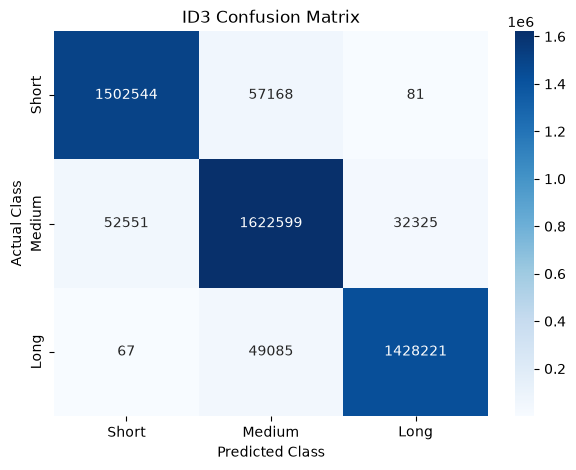

In [16]:
from sklearn.metrics import confusion_matrix

class_names = [
    "Short",
    "Medium",
    "Long"
]

# Create a weighted confusion matrix
matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names,
    sample_weight=weights_test
)

# Display the confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("ID3 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [ ]:
## 15. Feature Importance

#Feature importance explains which English sentence characteristics contributed most to the ID3 predictions.

In [17]:
# Create a feature-importance table
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": id3_model.feature_importances_
})

# Arrange from highest to lowest importance
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df

,feature,importance
0,english_word_count,0.879358
1,english_character_count,0.067256
2,punctuation_count,0.053272
3,has_question_mark,0.000114


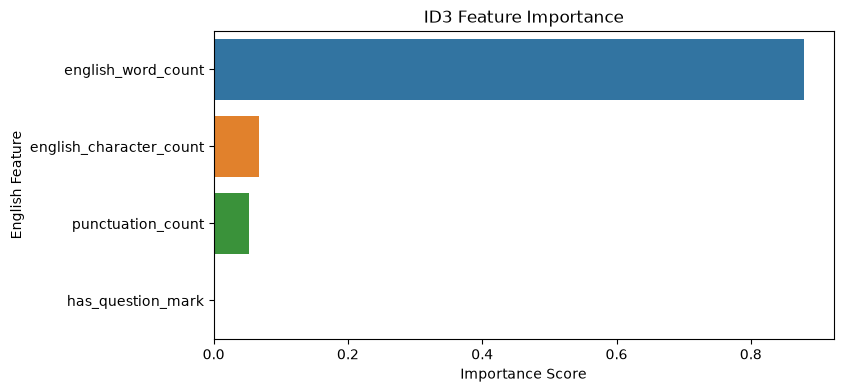

In [18]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    legend=False
)

plt.title("ID3 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("English Feature")
plt.show()

In [ ]:
## 16. Visualize the ID3 Decision Tree

#The first three levels of the tree are displayed to keep the learned decision rules readable.

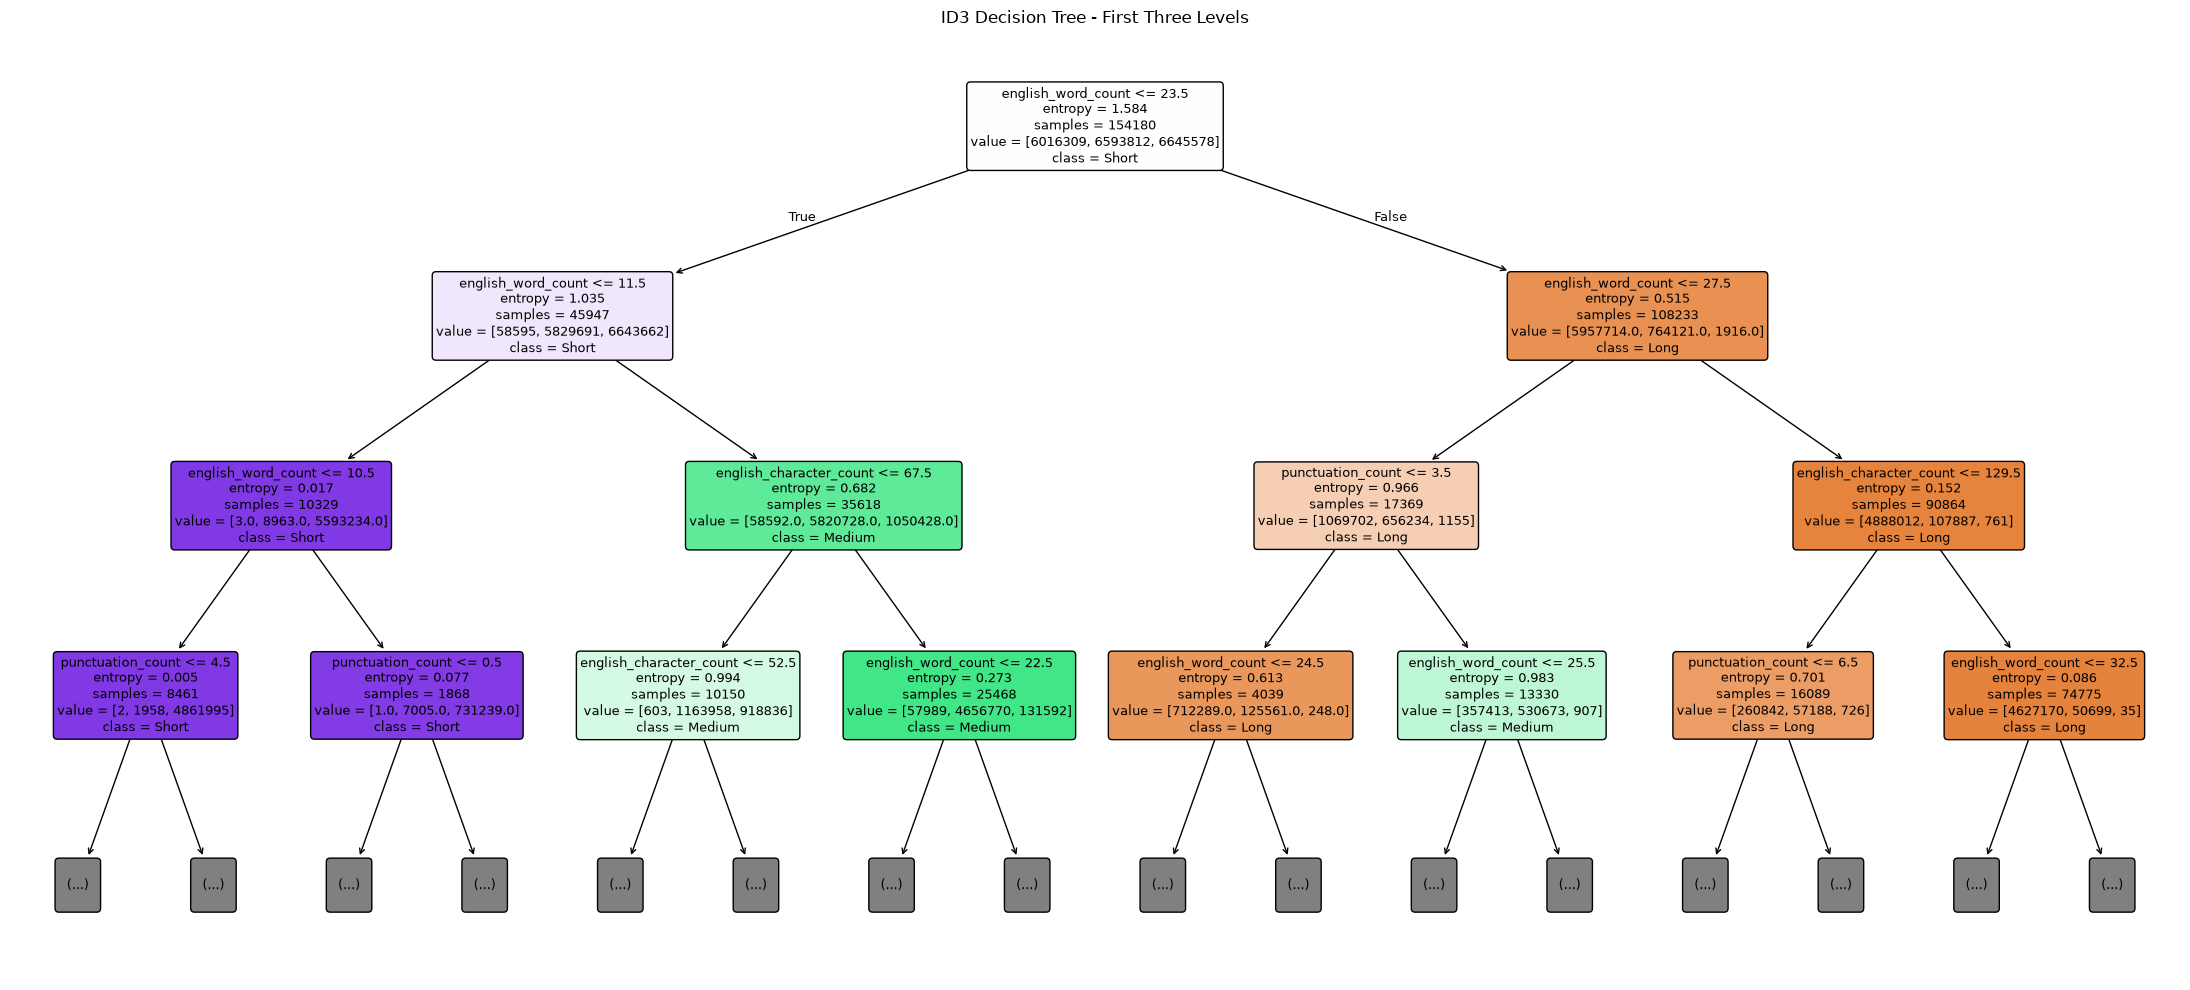

Tree image saved at:
C:\Users\HP\OneDrive\Documents\NeuraSign\results\aslg_pc12_id3_tree.png


In [19]:
from sklearn.tree import plot_tree

# Folder for saving project results
RESULTS_DIR = Path(
    r"C:\Users\HP\OneDrive\Documents\NeuraSign\results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

plt.figure(figsize=(22, 10))

plot_tree(
    id3_model,
    feature_names=X.columns,
    class_names=id3_model.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("ID3 Decision Tree - First Three Levels")
plt.tight_layout()

# Save the tree image
tree_image = RESULTS_DIR / "aslg_pc12_id3_tree.png"

plt.savefig(
    tree_image,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Tree image saved at:")
print(tree_image)

In [ ]:
## 17. Full ID3 Decision Tree

#The complete trained decision tree is exported as a high-quality PDF so every node and decision rule can be inspected.

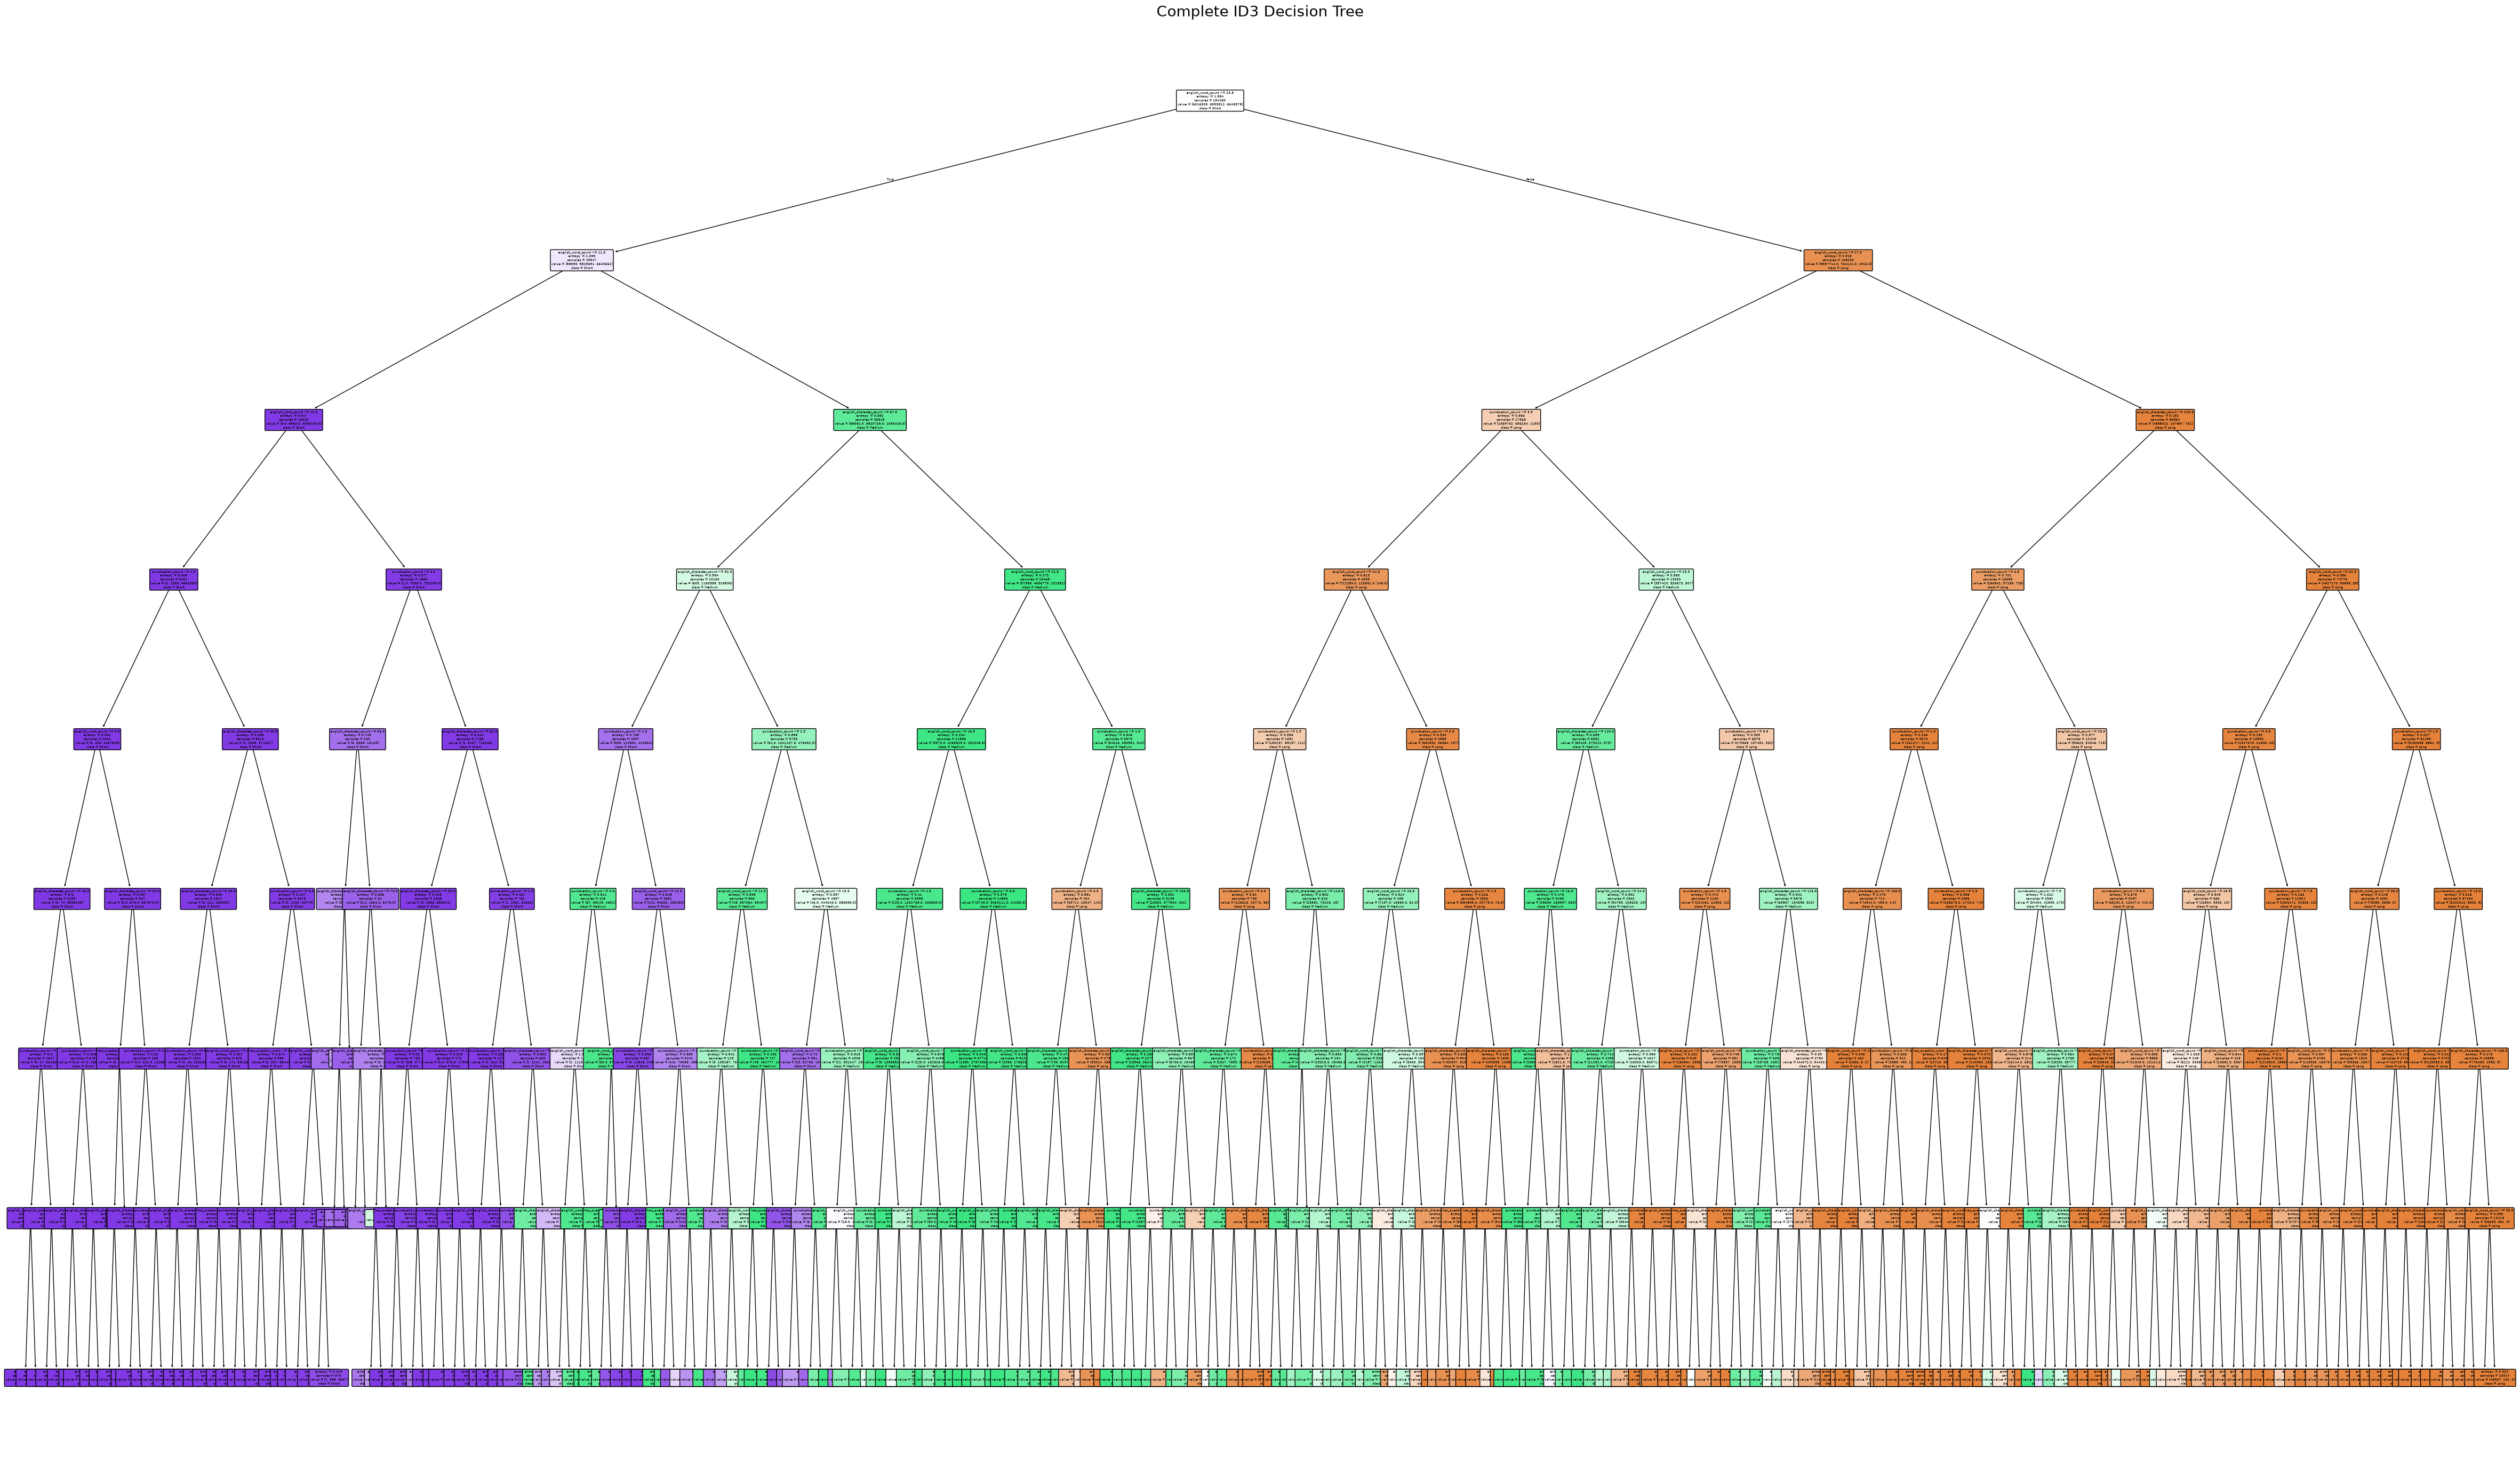

Full tree saved at:
C:\Users\HP\OneDrive\Documents\NeuraSign\results\aslg_pc12_full_id3_tree.pdf


In [20]:
# Create a large figure for the complete tree
plt.figure(figsize=(60, 35))

plot_tree(
    id3_model,
    feature_names=X.columns,
    class_names=id3_model.classes_,
    filled=True,
    rounded=True,
    fontsize=4
)

plt.title(
    "Complete ID3 Decision Tree",
    fontsize=20
)

# Save the complete tree as a zoomable PDF
full_tree_path = (
    RESULTS_DIR / "aslg_pc12_full_id3_tree.pdf"
)

plt.savefig(
    full_tree_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Full tree saved at:")
print(full_tree_path)

In [ ]:
## 18. Save the Trained Model and Results

#The trained ID3 model, evaluation metrics, feature names, and complexity boundaries are saved for future reuse.

In [21]:
import json
import joblib

# Create model folder
MODEL_DIR = Path(
    r"C:\Users\HP\OneDrive\Documents\NeuraSign\models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Save the trained model
model_path = MODEL_DIR / "aslg_pc12_id3_model.joblib"

joblib.dump(
    id3_model,
    model_path
)

# Save model information
model_info = {
    "model_name": "ASLG-PC12 ID3 Complexity Classifier",
    "criterion": "entropy",
    "short_limit": int(short_limit),
    "medium_limit": int(medium_limit),
    "features": X.columns.tolist(),
    "classes": id3_model.classes_.tolist(),
    "weighted_test_accuracy": float(accuracy),
    "valid_records_represented": int(total_valid)
}

info_path = RESULTS_DIR / "aslg_pc12_id3_info.json"

with open(
    info_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_info,
        file,
        indent=4
    )

print("Model saved at:")
print(model_path)

print("\nModel information saved at:")
print(info_path)

Model saved at:
C:\Users\HP\OneDrive\Documents\NeuraSign\models\aslg_pc12_id3_model.joblib

Model information saved at:
C:\Users\HP\OneDrive\Documents\NeuraSign\results\aslg_pc12_id3_info.json


In [ ]:
## 19. Conclusion

#The complete ASLG-PC12 dataset was validated and processed using a memory-efficient chunk-based workflow. Invalid English-ASL pairs were identified and excluded from supervised model preparation.

#An entropy-based ID3-style decision tree was trained to predict ASL gloss complexity from English sentence features. The model uses English word count, character count, punctuation count, and question-mark presence without using ASL target information as input.

#This model is a baseline complexity classifier, not a complete English-to-ASL translator. Future NeuraSign stages will require sequence-based NLP models for English-to-ASL gloss translation and continuous motion datasets for avatar generation.

In [22]:
print("=" * 55)
print("NEURASIGN ASLG-PC12 ID3 PROJECT SUMMARY")
print("=" * 55)

print("Original rows:", f"{total_rows_checked:,}")
print("Valid pairs:", f"{total_valid:,}")
print("Invalid pairs:", f"{invalid_pairs:,}")

print("\nComplexity limits:")
print("Short: gloss count <=", short_limit)
print(
    "Medium:",
    short_limit,
    "< gloss count <=",
    medium_limit
)
print("Long: gloss count >", medium_limit)

print("\nModel details:")
print("Algorithm: ID3-style Decision Tree")
print("Criterion: Entropy")
print("Tree depth:", id3_model.get_depth())
print("Tree leaves:", id3_model.get_n_leaves())
print("Weighted accuracy:", f"{accuracy * 100:.2f}%")

print("\nSaved outputs:")
print("Model:", model_path)
print("Model information:", info_path)
print("Full tree:", full_tree_path)

NEURASIGN ASLG-PC12 ID3 PROJECT SUMMARY
Original rows: 24,002,586
Valid pairs: 24,000,340
Invalid pairs: 2,246

Complexity limits:
Short: gloss count <= 10
Medium: 10 < gloss count <= 21
Long: gloss count > 21

Model details:
Algorithm: ID3-style Decision Tree
Criterion: Entropy
Tree depth: 8
Tree leaves: 244
Weighted accuracy: 95.97%

Saved outputs:
Model: C:\Users\HP\OneDrive\Documents\NeuraSign\models\aslg_pc12_id3_model.joblib
Model information: C:\Users\HP\OneDrive\Documents\NeuraSign\results\aslg_pc12_id3_info.json
Full tree: C:\Users\HP\OneDrive\Documents\NeuraSign\results\aslg_pc12_full_id3_tree.pdf
